
RELIANCE STOCK ANALYSIS
Data period       : 2026-06-01 to 2026-09-01
Trading days      : 66
Starting close    : ₹1,320.00
Latest close      : ₹1,309.00

First 10 historical records:
      DATE   OPEN   HIGH    LOW  CLOSE    VWAP   VOLUME
2026-06-01 1332.5 1335.5 1318.5 1320.0 1324.32 10700603
2026-06-02 1307.7 1327.8 1300.3 1314.6 1313.43 23302785
2026-06-03 1315.0 1324.0 1301.0 1313.2 1309.61 20012293
2026-06-04 1301.0 1311.2 1293.1 1303.7 1303.16 23474327
2026-06-05 1304.5 1306.0 1288.0 1291.0 1294.80 17785223
2026-06-08 1277.0 1282.6 1259.2 1263.3 1271.90 16494759
2026-06-09 1269.0 1274.2 1257.5 1269.2 1264.75 23620214
2026-06-10 1275.0 1300.5 1254.4 1258.8 1274.15 21012796
2026-06-11 1258.0 1276.0 1253.2 1263.0 1265.78 13117486
2026-06-12 1277.0 1297.0 1262.5 1293.0 1277.16 11988785

DESCRIPTIVE ANALYTICS
                   Metric       Value
                    Count   66.000000
               Mean Close 1302.748485
             Median Close 1307.800000
            Std Dev Close 

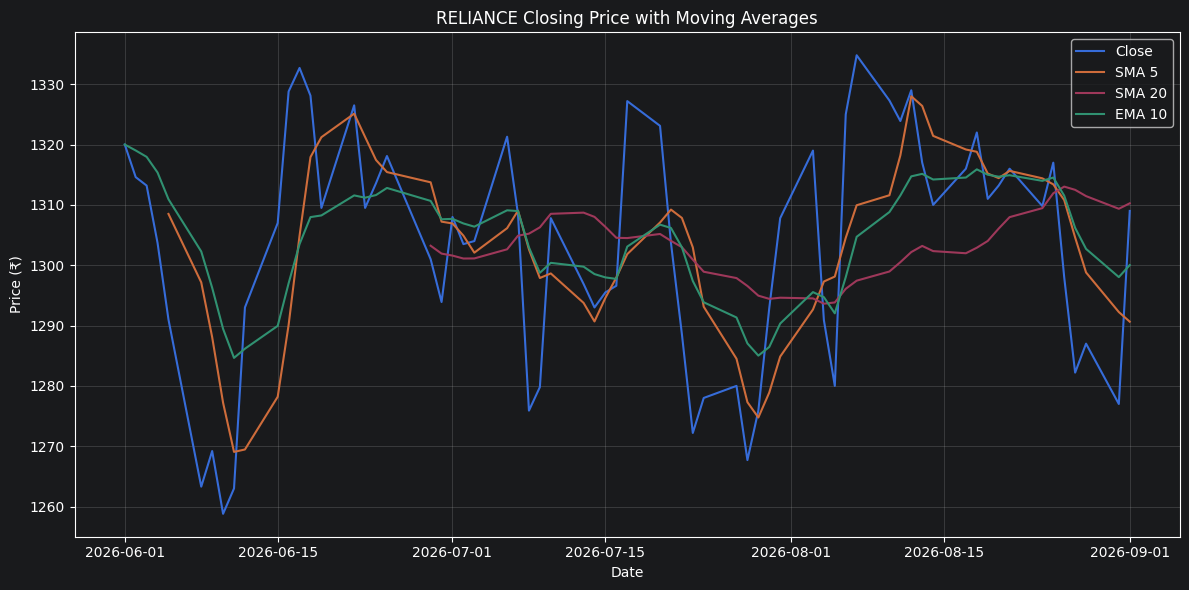

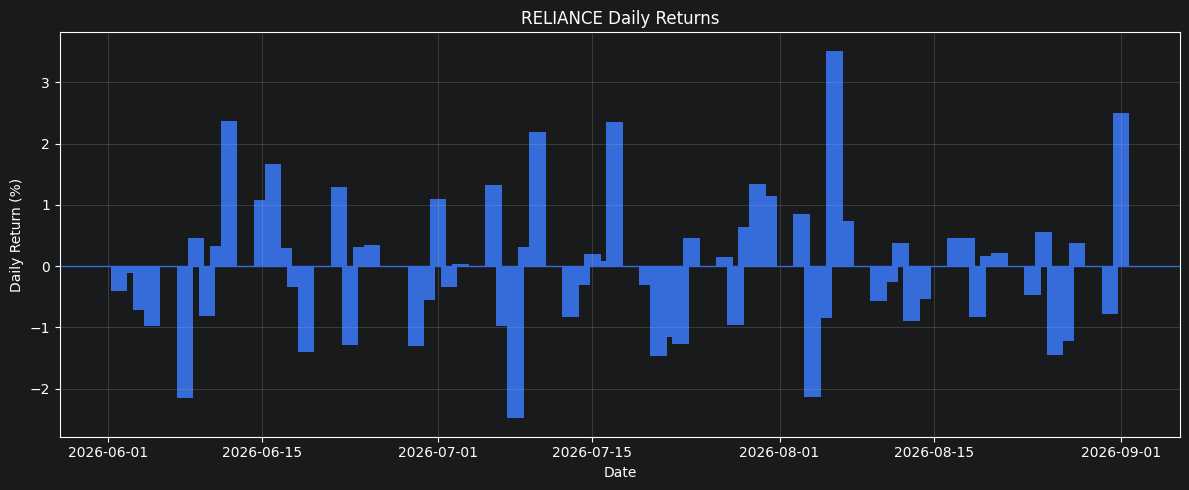

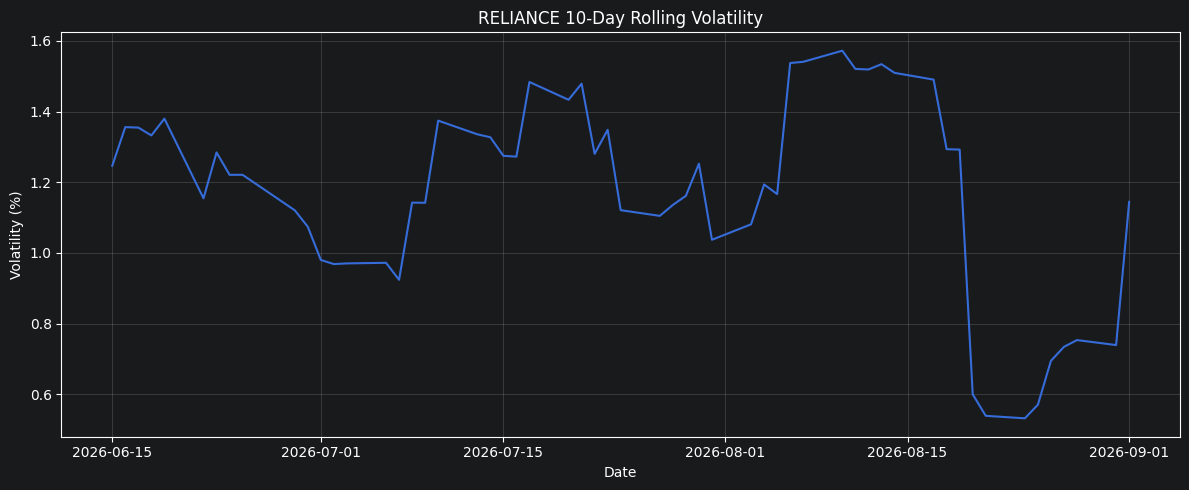

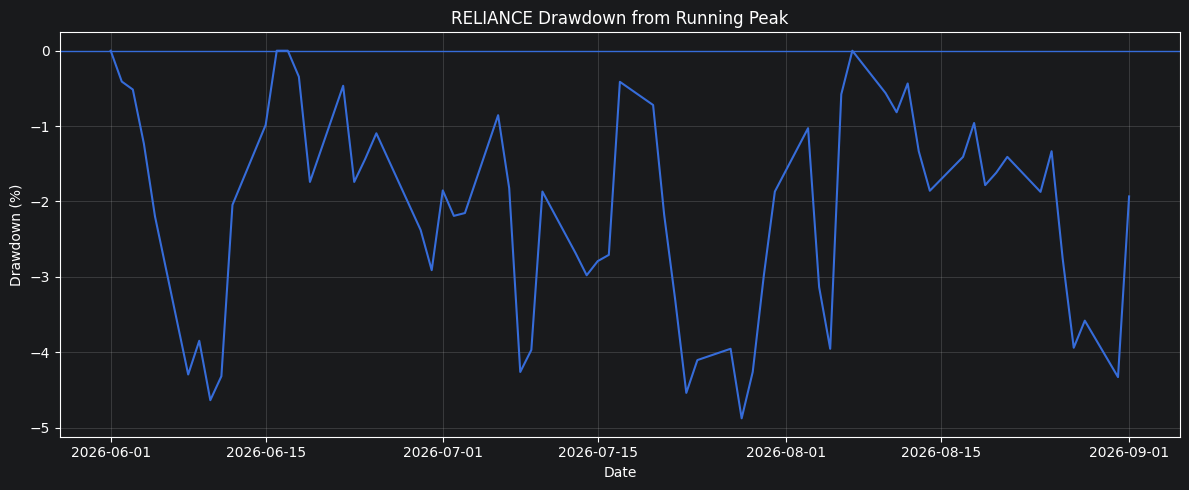

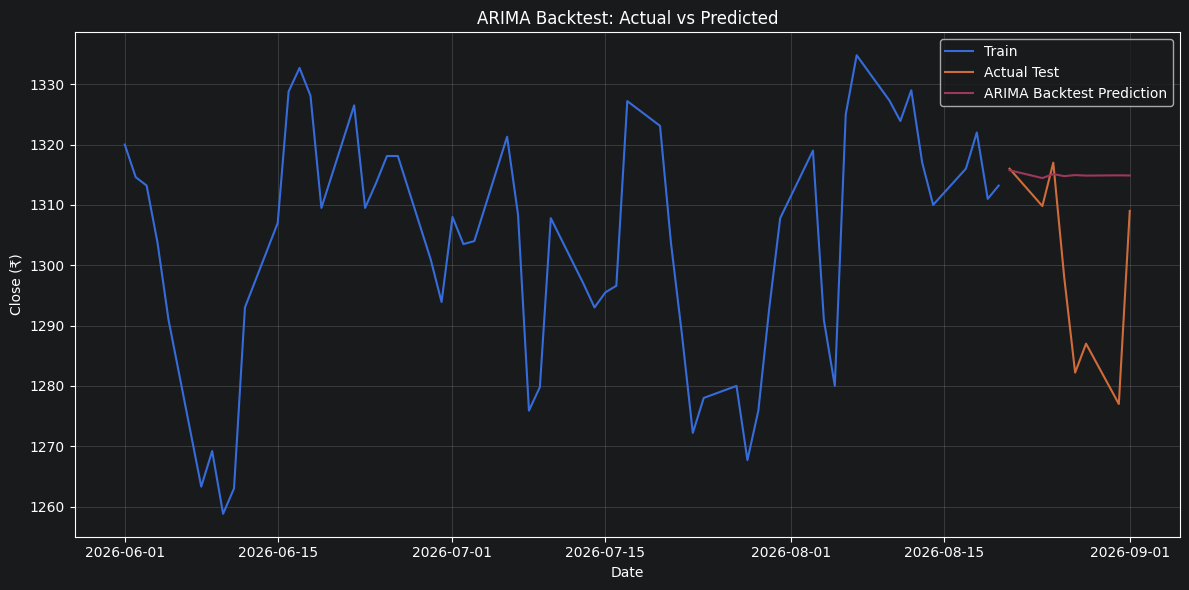

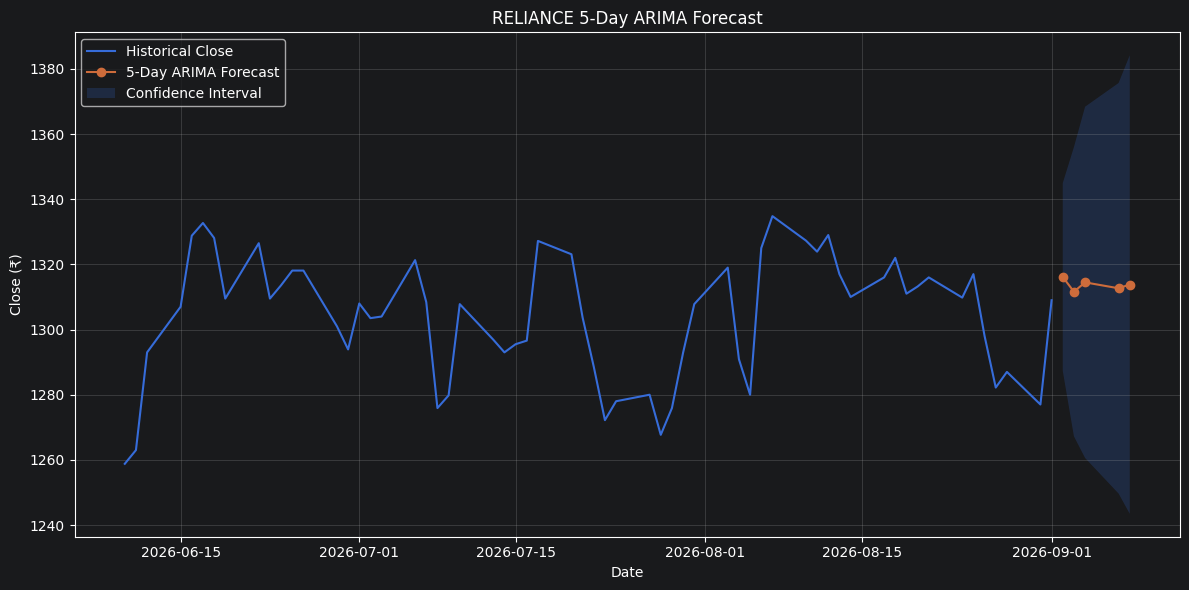


All outputs saved in: C:\Users\pravi\PycharmProjects\JupyterProject\Stock Data Analysis\reliance_analysis_output_1


In [2]:

# RELIANCE 3-Month Stock Analysis
# 1) Historical data
# 2) Descriptive analytics
# 3) Diagnostic analytics
# 4) Predictive analytics
# 5) 5-day ARIMA forecast
# 6) Visualizations

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

CSV_FILE = "Quote-Equity-RELIANCE-EQ-01-06-2026-01-09-2026.csv"
OUTPUT_DIR = Path("reliance_analysis_output_1")
OUTPUT_DIR.mkdir(exist_ok=True)

def clean_number(series):
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.replace("₹", "", regex=False),
        errors="coerce"
    )

# -----------------------------
# 1. LOAD + HISTORICAL DATA
# -----------------------------
df = pd.read_csv(CSV_FILE)

df["DATE"] = pd.to_datetime(df["DATE"], dayfirst=True, errors="coerce")

numeric_cols = [
    "OPEN", "HIGH", "LOW", "PREV. CLOSE", "LTP", "CLOSE", "VWAP",
    "52 WEEK HIGH", "52 WEEK LOW", "VOLUME", "VALUE", "NO. OF  TRADES"
]
for col in numeric_cols:
    df[col] = clean_number(df[col])

df = df.dropna(subset=["DATE", "CLOSE"]).sort_values("DATE").reset_index(drop=True)

# Engineered historical data
df["PRICE_CHANGE"] = df["CLOSE"].diff()
df["DAILY_RETURN_%"] = df["CLOSE"].pct_change() * 100
df["SMA_5"] = df["CLOSE"].rolling(5).mean()
df["SMA_20"] = df["CLOSE"].rolling(20).mean()
df["EMA_10"] = df["CLOSE"].ewm(span=10, adjust=False).mean()
df["VOLATILITY_10D_%"] = df["DAILY_RETURN_%"].rolling(10).std()
df["ROLLING_HIGH_20"] = df["CLOSE"].rolling(20).max()
df["DRAWDOWN_%"] = (df["CLOSE"] / df["CLOSE"].cummax() - 1) * 100

df.to_csv(OUTPUT_DIR / "01_historical_and_engineered_data.csv", index=False)

print("\n" + "="*65)
print("RELIANCE STOCK ANALYSIS")
print("="*65)
print(f"Data period       : {df['DATE'].min().date()} to {df['DATE'].max().date()}")
print(f"Trading days      : {len(df)}")
print(f"Starting close    : ₹{df['CLOSE'].iloc[0]:,.2f}")
print(f"Latest close      : ₹{df['CLOSE'].iloc[-1]:,.2f}")
print("\nFirst 10 historical records:")
print(df[["DATE","OPEN","HIGH","LOW","CLOSE","VWAP","VOLUME"]].head(10).to_string(index=False))

# -----------------------------
# 2. DESCRIPTIVE ANALYTICS
# -----------------------------
returns = df["DAILY_RETURN_%"].dropna()

descriptive = pd.DataFrame({
    "Metric": [
        "Count", "Mean Close", "Median Close", "Std Dev Close",
        "Minimum Close", "Maximum Close", "Mean Daily Return (%)",
        "Median Daily Return (%)", "Daily Return Std Dev (%)",
        "Total Period Return (%)", "Up Days", "Down Days",
        "Best Day (%)", "Worst Day (%)", "Annualized Volatility (%)"
    ],
    "Value": [
        len(df),
        df["CLOSE"].mean(),
        df["CLOSE"].median(),
        df["CLOSE"].std(),
        df["CLOSE"].min(),
        df["CLOSE"].max(),
        returns.mean(),
        returns.median(),
        returns.std(),
        (df["CLOSE"].iloc[-1] / df["CLOSE"].iloc[0] - 1) * 100,
        int((returns > 0).sum()),
        int((returns < 0).sum()),
        returns.max(),
        returns.min(),
        returns.std() * np.sqrt(252)
    ]
})
descriptive.to_csv(OUTPUT_DIR / "02_descriptive_analytics.csv", index=False)

print("\nDESCRIPTIVE ANALYTICS")
print(descriptive.to_string(index=False))

# -----------------------------
# 3. DIAGNOSTIC ANALYTICS
# -----------------------------
best_day_idx = df["DAILY_RETURN_%"].idxmax()
worst_day_idx = df["DAILY_RETURN_%"].idxmin()
max_dd_idx = df["DRAWDOWN_%"].idxmin()

diagnostic = pd.DataFrame({
    "Metric": [
        "Best return day",
        "Best return (%)",
        "Worst return day",
        "Worst return (%)",
        "Maximum drawdown (%)",
        "Maximum drawdown date",
        "Average daily volume",
        "Highest volume date",
        "Highest volume",
        "Latest SMA 5",
        "Latest SMA 20",
        "Latest EMA 10",
        "Latest 10-day volatility (%)",
        "Trend vs SMA 20"
    ],
    "Value": [
        df.loc[best_day_idx, "DATE"].date(),
        df.loc[best_day_idx, "DAILY_RETURN_%"],
        df.loc[worst_day_idx, "DATE"].date(),
        df.loc[worst_day_idx, "DAILY_RETURN_%"],
        df.loc[max_dd_idx, "DRAWDOWN_%"],
        df.loc[max_dd_idx, "DATE"].date(),
        df["VOLUME"].mean(),
        df.loc[df["VOLUME"].idxmax(), "DATE"].date(),
        df["VOLUME"].max(),
        df["SMA_5"].iloc[-1],
        df["SMA_20"].iloc[-1],
        df["EMA_10"].iloc[-1],
        df["VOLATILITY_10D_%"].iloc[-1],
        "Bullish" if df["CLOSE"].iloc[-1] > df["SMA_20"].iloc[-1] else "Bearish"
    ]
})
diagnostic.to_csv(OUTPUT_DIR / "03_diagnostic_analytics.csv", index=False)

print("\nDIAGNOSTIC ANALYTICS")
print(diagnostic.to_string(index=False))

# -----------------------------
# 4. PREDICTIVE ANALYTICS - ARIMA BACKTEST
# -----------------------------
# For a small time-series dataset, use a chronological holdout.
series = df.set_index("DATE")["CLOSE"].asfreq("B").ffill()

# Backtest on the last 10 observed trading values.
# The reindexed series has business-day frequency, so holidays/weekends are forward-filled.
# We preserve chronological order and evaluate only on held-out dates.
test_size = min(10, max(5, len(series) // 8))
train = series.iloc[:-test_size]
test = series.iloc[-test_size:]

order = (1, 1, 1)
model = ARIMA(train, order=order)
fit = model.fit()
pred = fit.forecast(steps=test_size)

mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))

predictive = pd.DataFrame({
    "Metric": ["ARIMA Order", "Test Size", "MAE", "RMSE"],
    "Value": [str(order), test_size, mae, rmse]
})
predictive.to_csv(OUTPUT_DIR / "04_predictive_analytics.csv", index=False)

backtest = pd.DataFrame({
    "DATE": test.index,
    "ACTUAL_CLOSE": test.values,
    "ARIMA_PREDICTED_CLOSE": pred.values
})
backtest.to_csv(OUTPUT_DIR / "05_arima_backtest.csv", index=False)

print("\nPREDICTIVE ANALYTICS")
print(predictive.to_string(index=False))
print("\nARIMA BACKTEST")
print(backtest.to_string(index=False))

# -----------------------------
# 5. 5-DAY ARIMA FORECAST
# -----------------------------
full_model = ARIMA(series, order=order)
full_fit = full_model.fit()
forecast = full_fit.forecast(steps=5)
forecast_ci = full_fit.get_forecast(steps=5).conf_int()

forecast_dates = pd.bdate_range(series.index[-1] + pd.Timedelta(days=1), periods=5)
forecast_df = pd.DataFrame({
    "DATE": forecast_dates,
    "FORECAST_CLOSE": forecast.values,
    "LOWER_CI": forecast_ci.iloc[:, 0].values,
    "UPPER_CI": forecast_ci.iloc[:, 1].values
})
forecast_df.to_csv(OUTPUT_DIR / "06_five_day_arima_forecast.csv", index=False)

print("\n5-DAY ARIMA FORECAST")
print(forecast_df.to_string(index=False))

# -----------------------------
# 6. VISUALIZATIONS
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(df["DATE"], df["CLOSE"], label="Close")
plt.plot(df["DATE"], df["SMA_5"], label="SMA 5")
plt.plot(df["DATE"], df["SMA_20"], label="SMA 20")
plt.plot(df["DATE"], df["EMA_10"], label="EMA 10")
plt.title("RELIANCE Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_price_moving_averages.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(df["DATE"], df["DAILY_RETURN_%"], width=1.5)
plt.axhline(0, linewidth=1)
plt.title("RELIANCE Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_daily_returns.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["DATE"], df["VOLATILITY_10D_%"])
plt.title("RELIANCE 10-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_rolling_volatility.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["DATE"], df["DRAWDOWN_%"])
plt.axhline(0, linewidth=1)
plt.title("RELIANCE Drawdown from Running Peak")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "10_drawdown.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual Test")
plt.plot(pred.index, pred, label="ARIMA Backtest Prediction")
plt.title("ARIMA Backtest: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Close (₹)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "11_arima_backtest.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(series.index[-60:], series.iloc[-60:], label="Historical Close")
plt.plot(forecast_dates, forecast.values, marker="o", label="5-Day ARIMA Forecast")
plt.fill_between(
    forecast_dates,
    forecast_ci.iloc[:, 0].values,
    forecast_ci.iloc[:, 1].values,
    alpha=0.2,
    label="Confidence Interval"
)
plt.title("RELIANCE 5-Day ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Close (₹)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "12_five_day_arima_forecast.png", dpi=150)
plt.show()

print("\nAll outputs saved in:", OUTPUT_DIR.resolve())
